# Homework 3: Sequence-to-Sequence Machine Translation

**Name:** Gilberto Feliu  
**Student ID:** 801257813  
**Assignment:** Homework 3

This notebook runs the original PyTorch implementation in `src/seq2seq_hw3.py`. It uses one deterministic 80/20 split for all four required experiments.

## Setup

Place the provided dataset at `data/vast_english_french.txt` before running the notebook.

In [1]:
from pathlib import Path
ROOT = Path.cwd()
DATA = ROOT / 'data' / 'vast_english_french.txt'
print('Working directory:', ROOT)
print('Dataset exists:', DATA.exists())
if not DATA.exists():
    raise FileNotFoundError('Place vast_english_french.txt in Homework_3/data/ before executing this notebook.')

Working directory: /home/gilberto/Homework_3
Dataset exists: True


## Training Command

In [2]:
print('Full experiment command used for the saved results:')
print('python src/seq2seq_hw3.py --data data/vast_english_french.txt --epochs 60 --batch-size 96 --hidden-dim 160 --emb-dim 128')

Full experiment command used for the saved results:
python src/seq2seq_hw3.py --data data/vast_english_french.txt --epochs 60 --batch-size 96 --hidden-dim 160 --emb-dim 128


The command above trains all four required experiments and saves CSV files to `results/` and figures to `plots/`. It is shown here to make the executed notebook lightweight while still tying the visible outputs to the repository code.

## Summary Metrics

In [3]:
import pandas as pd
summary = pd.read_csv('results/summary.csv')
summary[['experiment', 'direction', 'architecture', 'best_val_loss', 'exact_match', 'word_bleu4', 'char_bleu4', 'sequence_similarity']]

,experiment,direction,architecture,best_val_loss,exact_match,word_bleu4,char_bleu4,sequence_similarity
0,problem1_baseline_en_fr,English-to-French,Baseline GRU encoder-decoder,5.222671,0.0,0.027622,0.146266,0.428932
1,problem2_attention_en_fr,English-to-French,GRU with Luong attention,5.014628,0.0,0.058861,0.243125,0.468759
2,problem3_baseline_fr_en,French-to-English,Baseline GRU encoder-decoder,4.830242,0.0,0.024932,0.141364,0.422941
3,problem3_attention_fr_en,French-to-English,GRU with Luong attention,4.685537,0.0,0.077093,0.248131,0.469708


## Qualitative Samples

In [4]:
import pandas as pd
for path in sorted(Path('results').glob('*_samples.csv')):
    print('\n', path.name)
    display(pd.read_csv(path))


 problem1_baseline_en_fr_samples.csv


,source,reference,prediction,exact_match,sentence_bleu4,char_accuracy,sequence_similarity
0,i can see a large cruise ship in the distance,je peux voir un grand navire de croisiere au loin,je veux une une de de la,0,0.1339,0.2041,0.4932
1,she is looking for her lost dog,elle cherche son chien perdu,elle a des des pour,0,0.2730,0.2143,0.4681
2,he finished his homework quickly,il a fini ses devoirs rapidement,il a la chimie de,0,0.2942,0.1562,0.4490
3,we prefer walking through the quiet botanical ...,nous preferons nous promener dans les jardins ...,nous avons visite le lever de la,0,0.1396,0.1111,0.4000
4,they visit museums often,ils visitent souvent des musees,ils parlent souvent de,0,0.3097,0.1290,0.6792



 problem2_attention_en_fr_samples.csv


,source,reference,prediction,exact_match,sentence_bleu4,char_accuracy,sequence_similarity
0,i can see a large cruise ship in the distance,je peux voir un grand navire de croisiere au loin,ils ont dans un navire au,0,0.1349,0.1224,0.4054
1,she is looking for her lost dog,elle cherche son chien perdu,elle cherche des contrats pour,0,0.3593,0.5357,0.6552
2,he finished his homework quickly,il a fini ses devoirs rapidement,il ecrit des scenarios,0,0.2179,0.1562,0.3704
3,we prefer walking through the quiet botanical ...,nous preferons nous promener dans les jardins ...,nous avons traverse la sur le parc,0,0.1396,0.0952,0.4536
4,they visit museums often,ils visitent souvent des musees,ils ont de la,0,0.2798,0.1613,0.5000



 problem3_attention_fr_en_samples.csv


,source,reference,prediction,exact_match,sentence_bleu4,char_accuracy,sequence_similarity
0,je peux voir un grand navire de croisiere au loin,i can see a large cruise ship in the distance,i see a a a ship the,0,0.1894,0.1333,0.5846
1,elle cherche son chien perdu,she is looking for her lost dog,she is looking for her,0,0.6703,0.7097,0.8302
2,il a fini ses devoirs rapidement,he finished his homework quickly,he cleans his his his bicycle,0,0.2445,0.0938,0.4918
3,nous preferons nous promener dans les jardins ...,we prefer walking through the quiet botanical ...,we are going to the the the,0,0.1782,0.0943,0.5000
4,ils visitent souvent des musees,they visit museums often,they often talk about modern,0,0.3021,0.2500,0.3846



 problem3_baseline_fr_en_samples.csv


,source,reference,prediction,exact_match,sentence_bleu4,char_accuracy,sequence_similarity
0,je peux voir un grand navire de croisiere au loin,i can see a large cruise ship in the distance,i want a a a the of,0,0.1439,0.0889,0.4375
1,elle cherche son chien perdu,she is looking for her lost dog,she is looking for a,0,0.5093,0.6129,0.7451
2,il a fini ses devoirs rapidement,he finished his homework quickly,he writes his for a,0,0.3021,0.0938,0.5098
3,nous preferons nous promener dans les jardins ...,we prefer walking through the quiet botanical ...,we are going to the the,0,0.1752,0.0943,0.4737
4,ils visitent souvent des musees,they visit museums often,they often talk about,0,0.3976,0.2500,0.4444


## Loss Curves and Attention Maps

plots/problem1_baseline_en_fr_loss.png


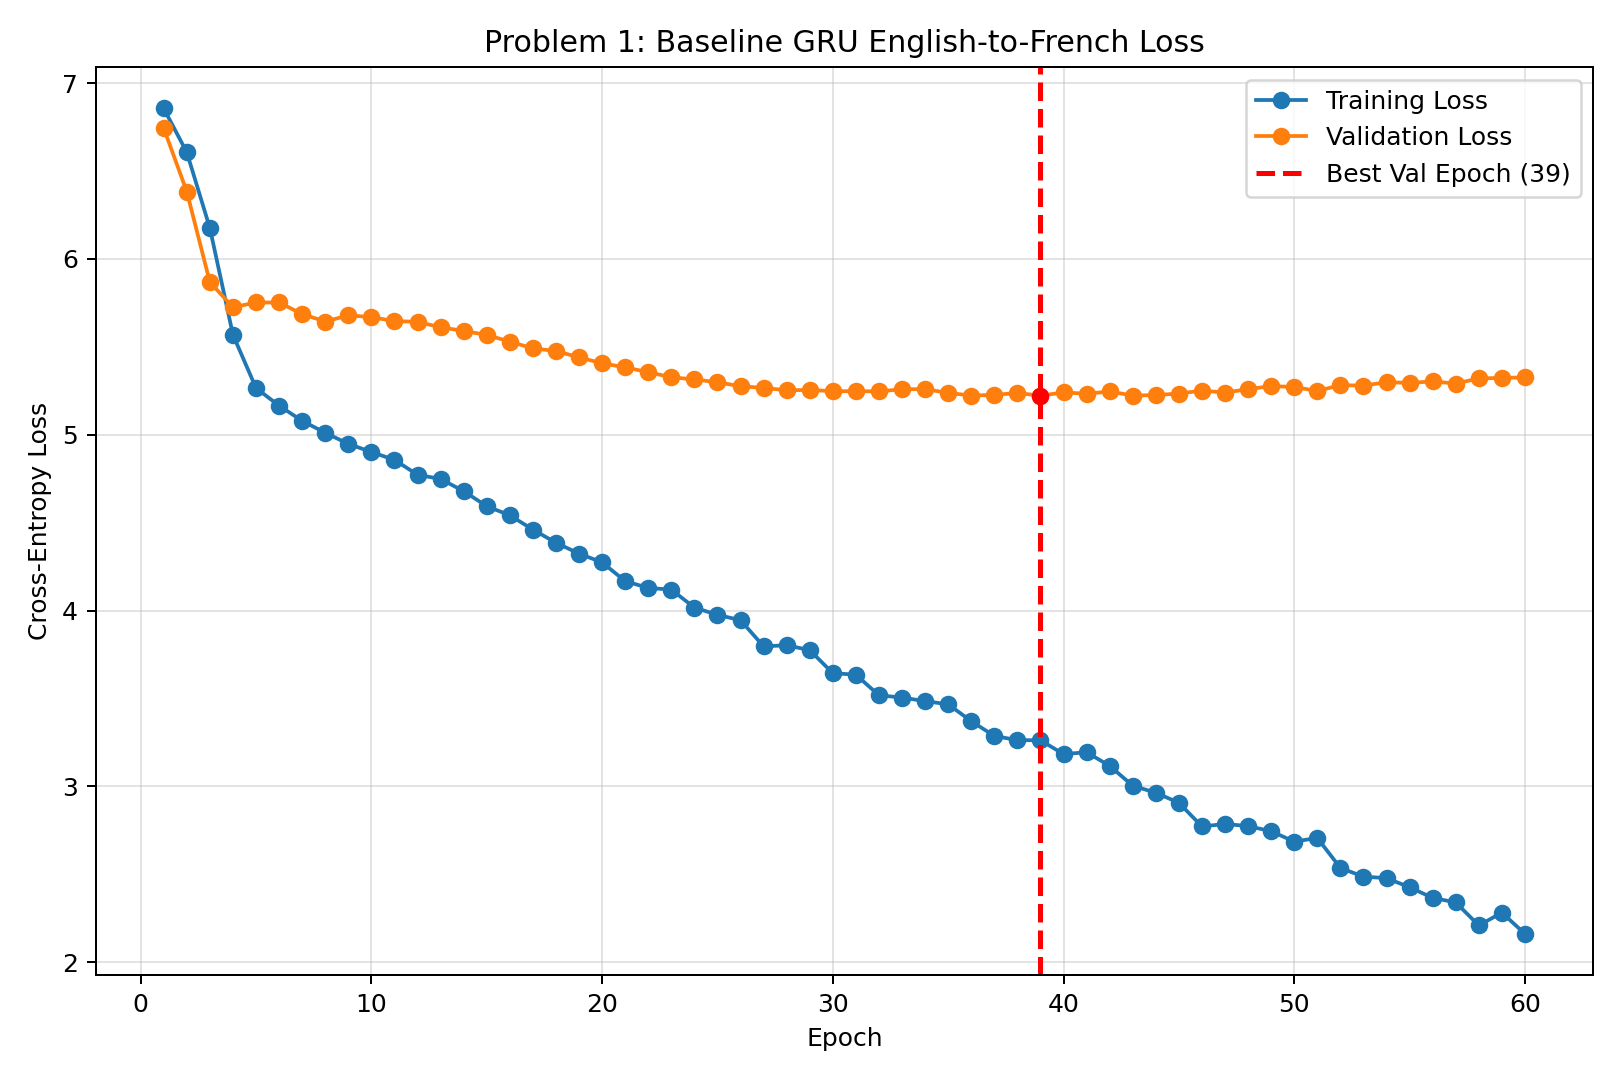

plots/problem1_vs_problem2_comparison.png


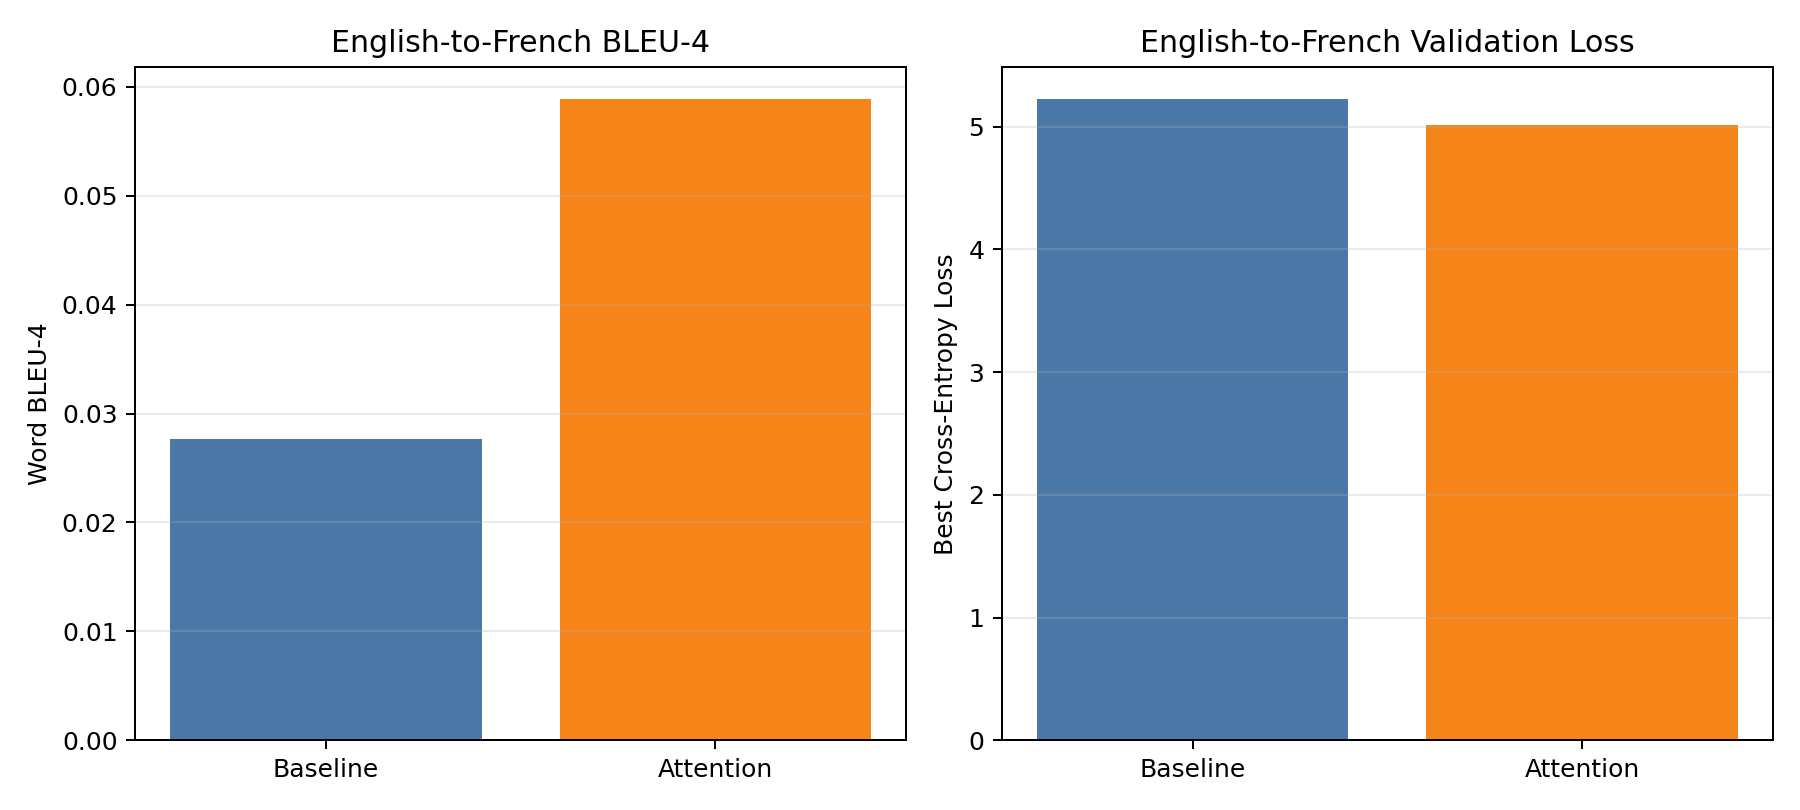

plots/problem2_attention_en_fr_attention_1.png


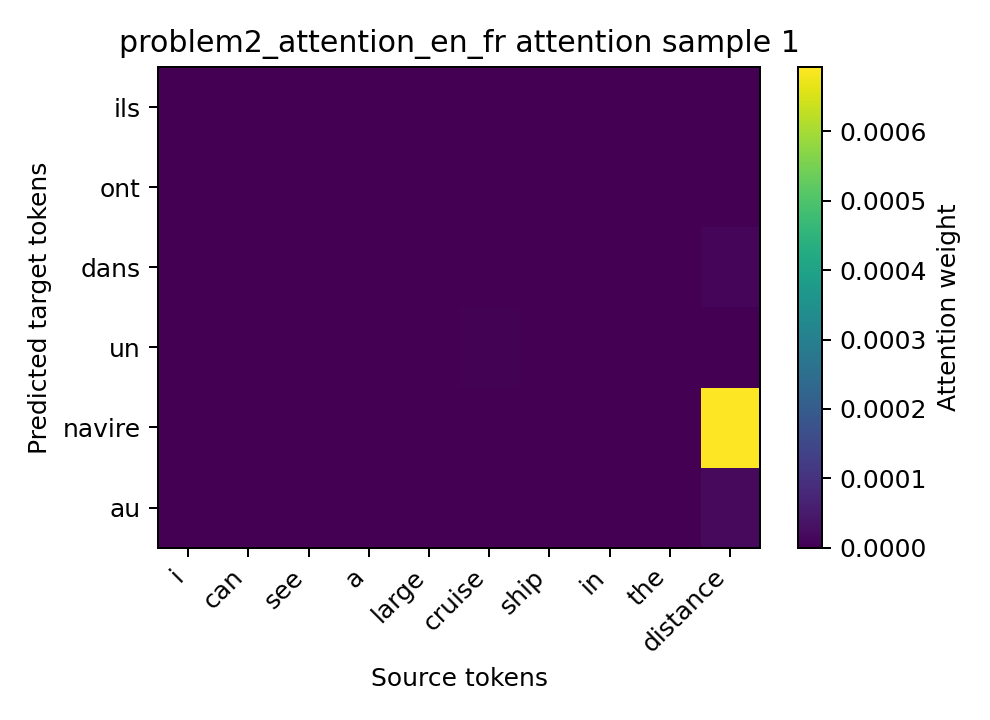

plots/problem2_attention_en_fr_attention_2.png


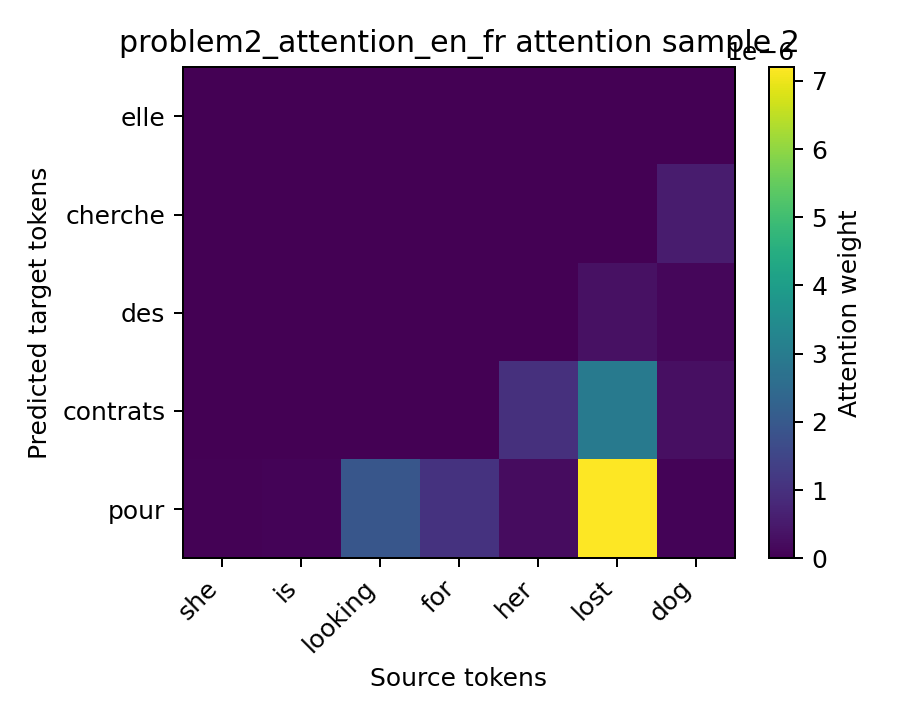

plots/problem2_attention_en_fr_loss.png


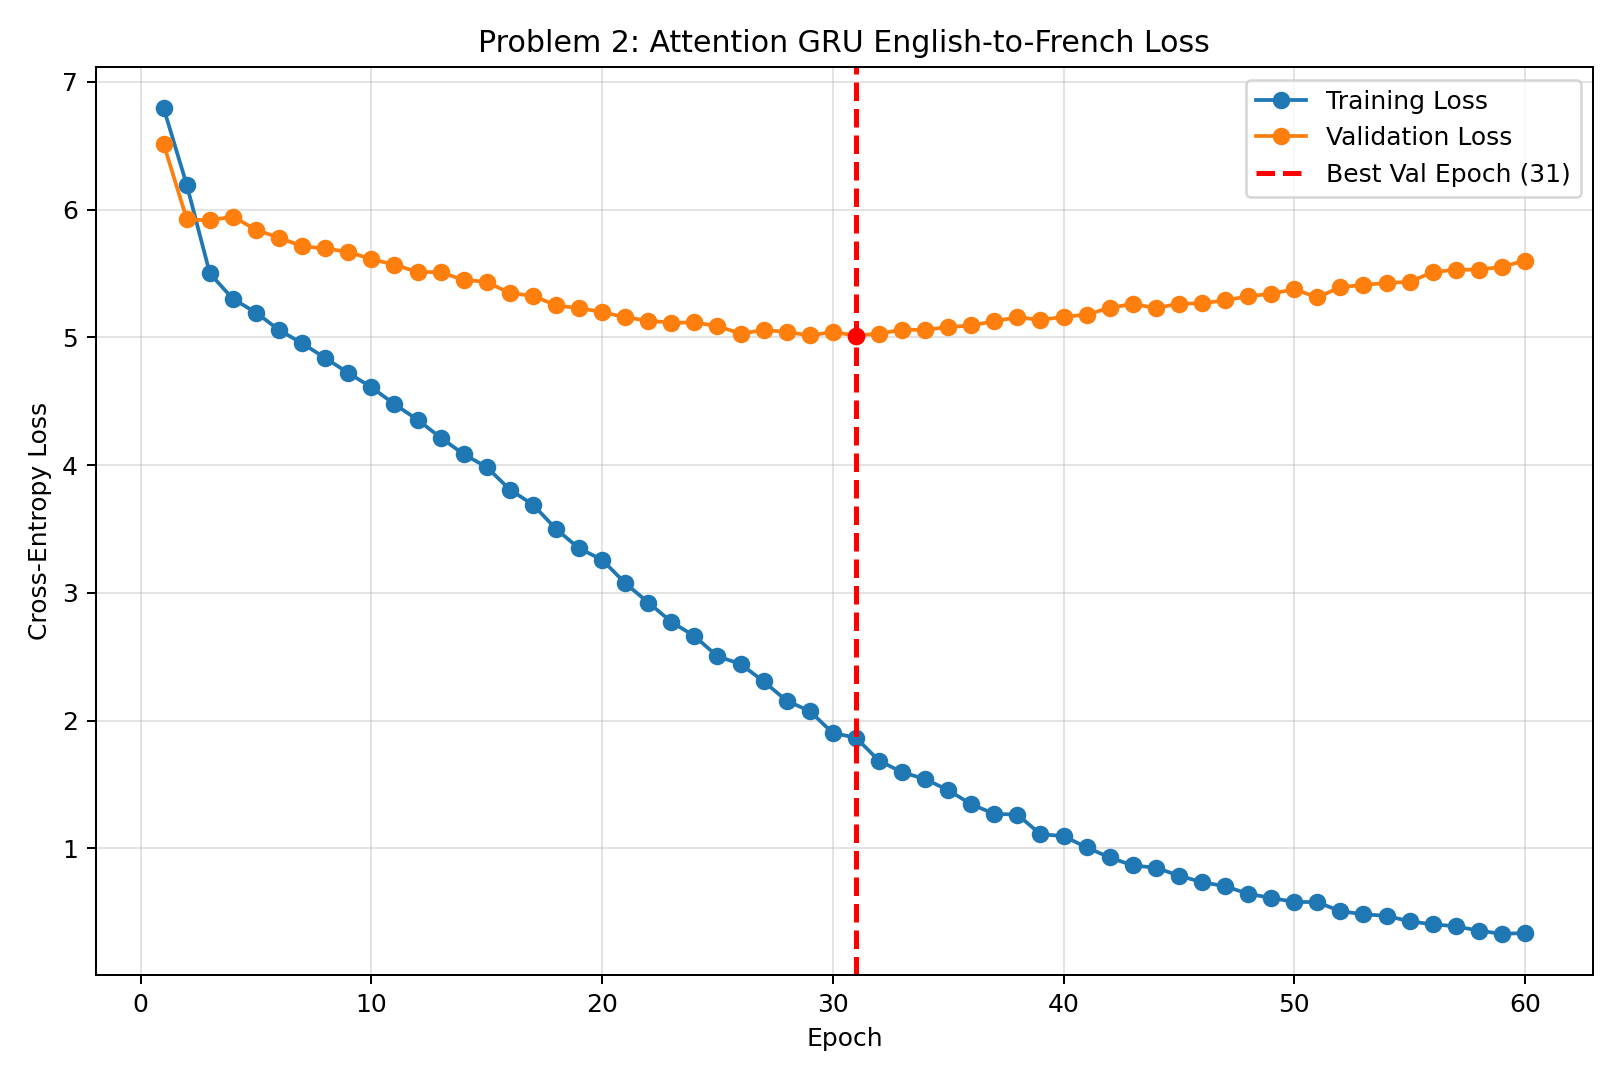

plots/problem3_attention_fr_en_attention_1.png


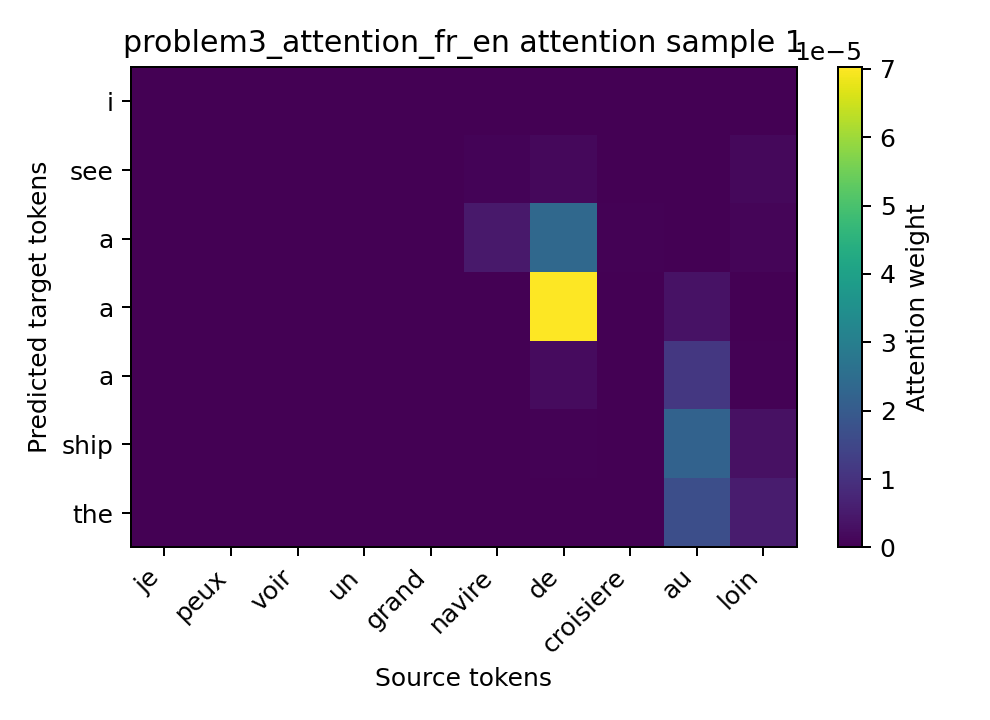

plots/problem3_attention_fr_en_attention_2.png


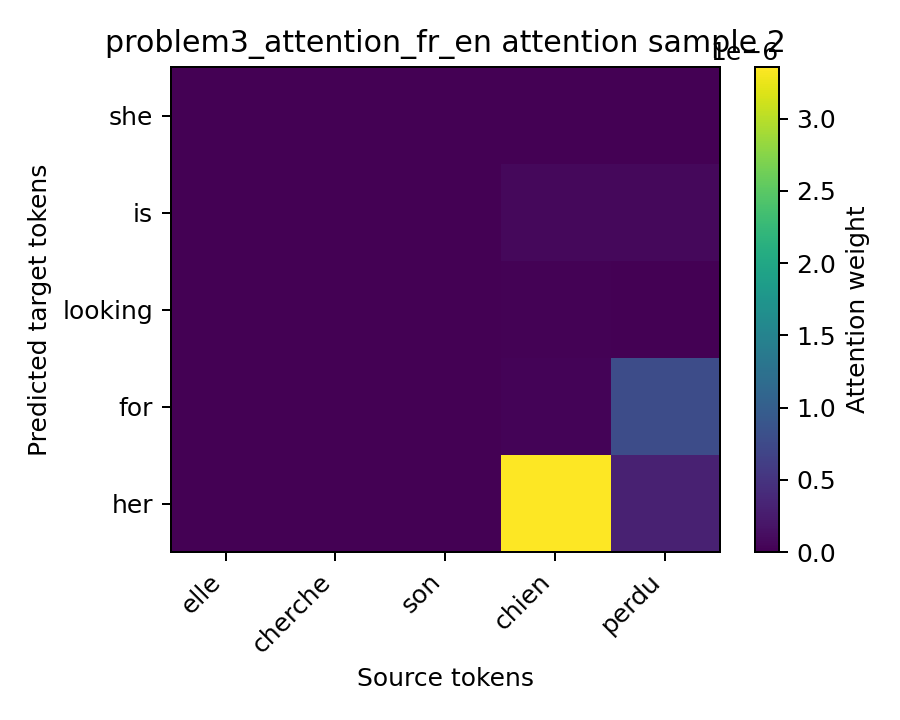

plots/problem3_attention_fr_en_loss.png


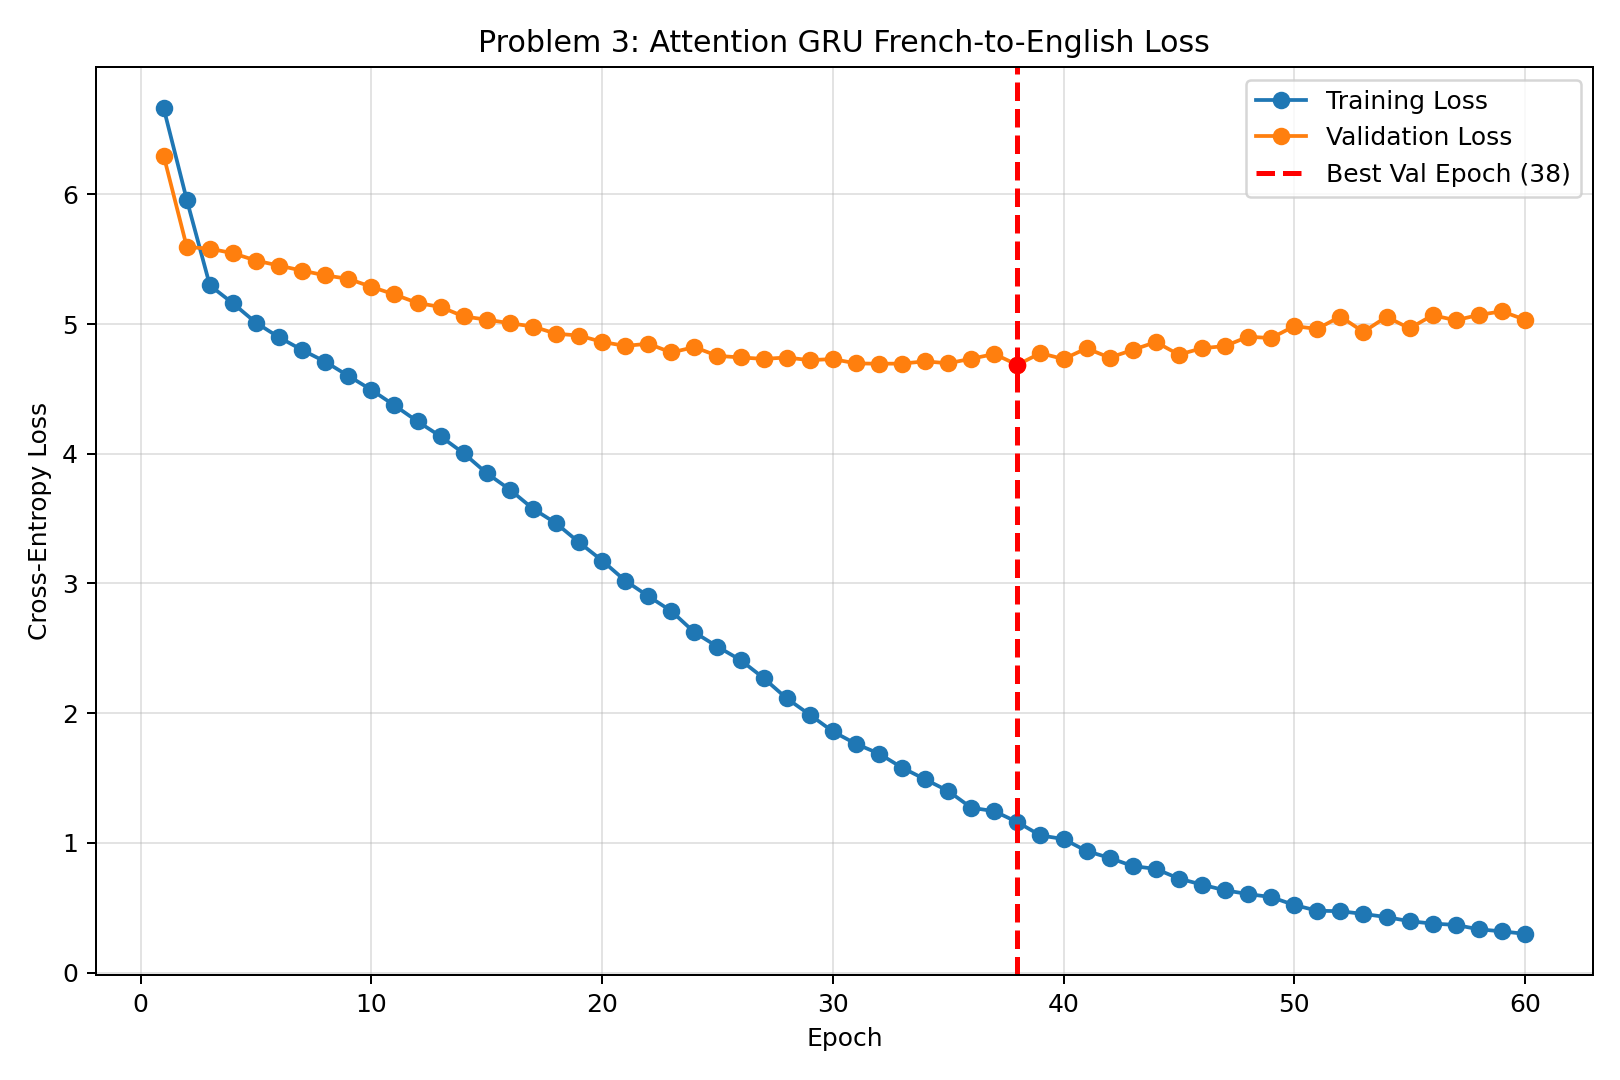

plots/problem3_baseline_fr_en_loss.png


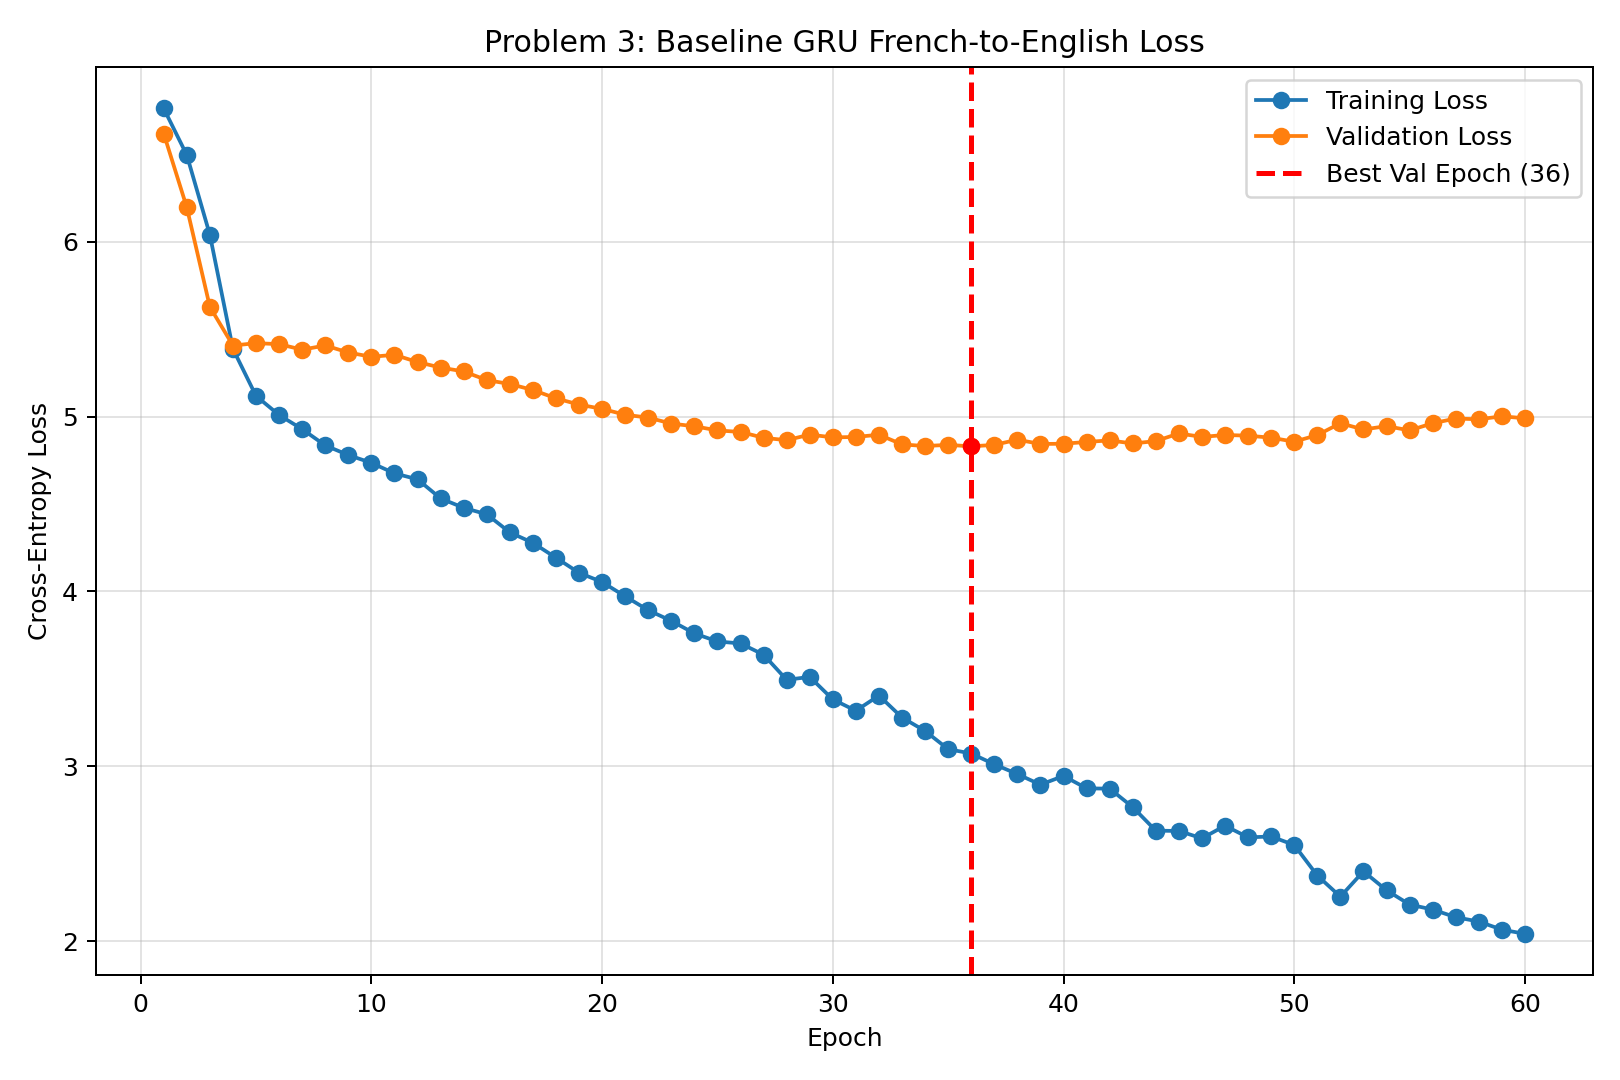

plots/problem3_full_bleu_comparison.png


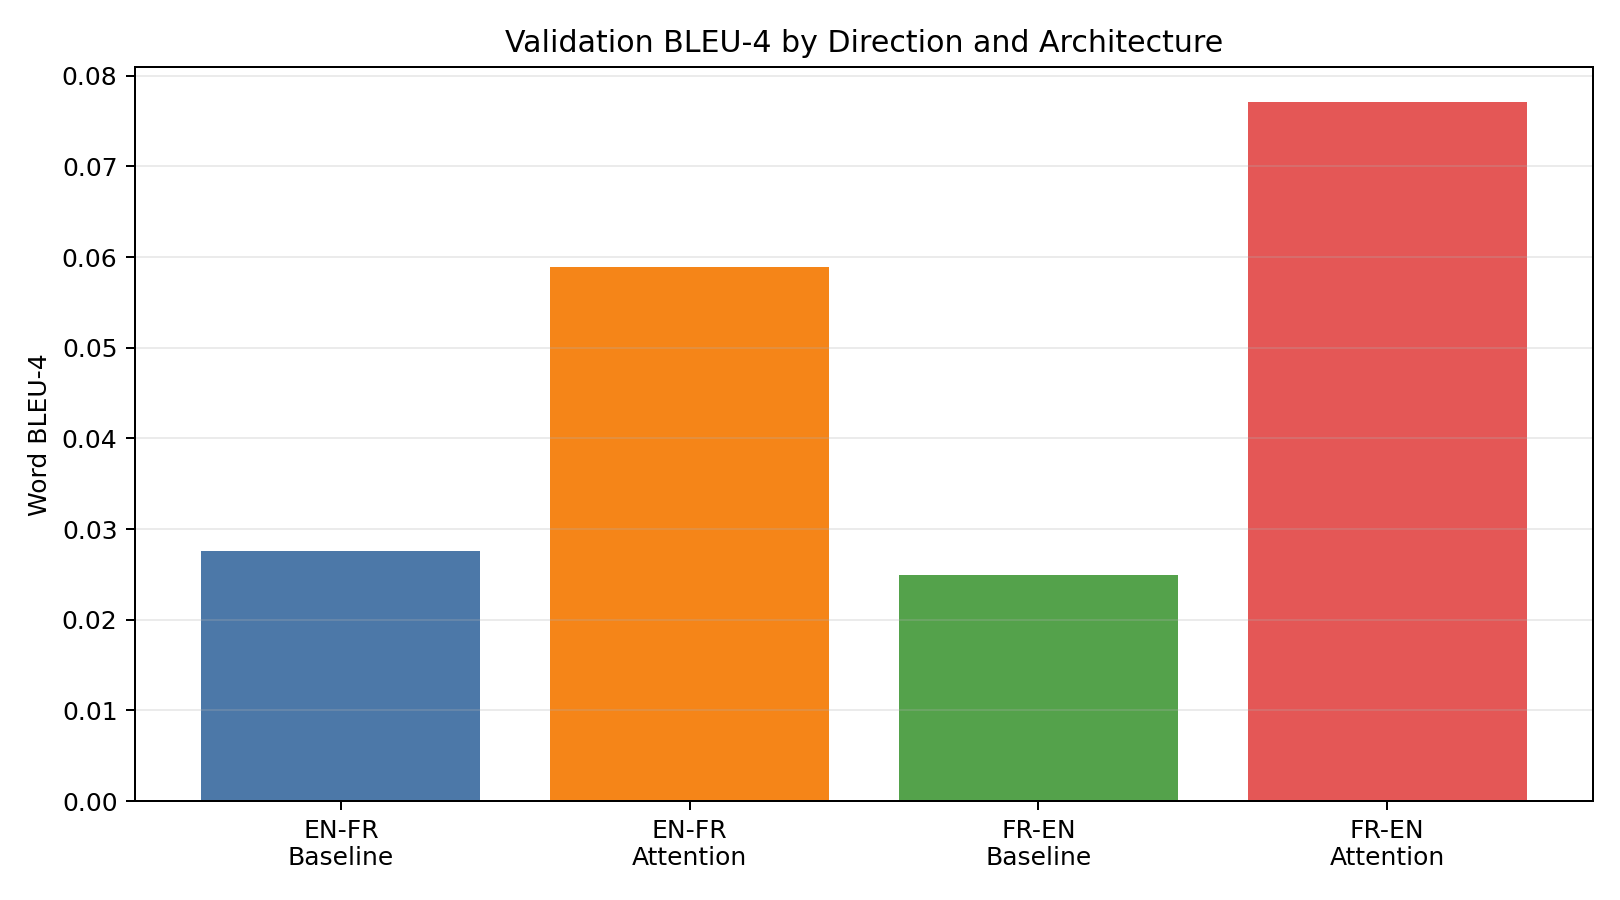

plots/problem3_model_comparison.png


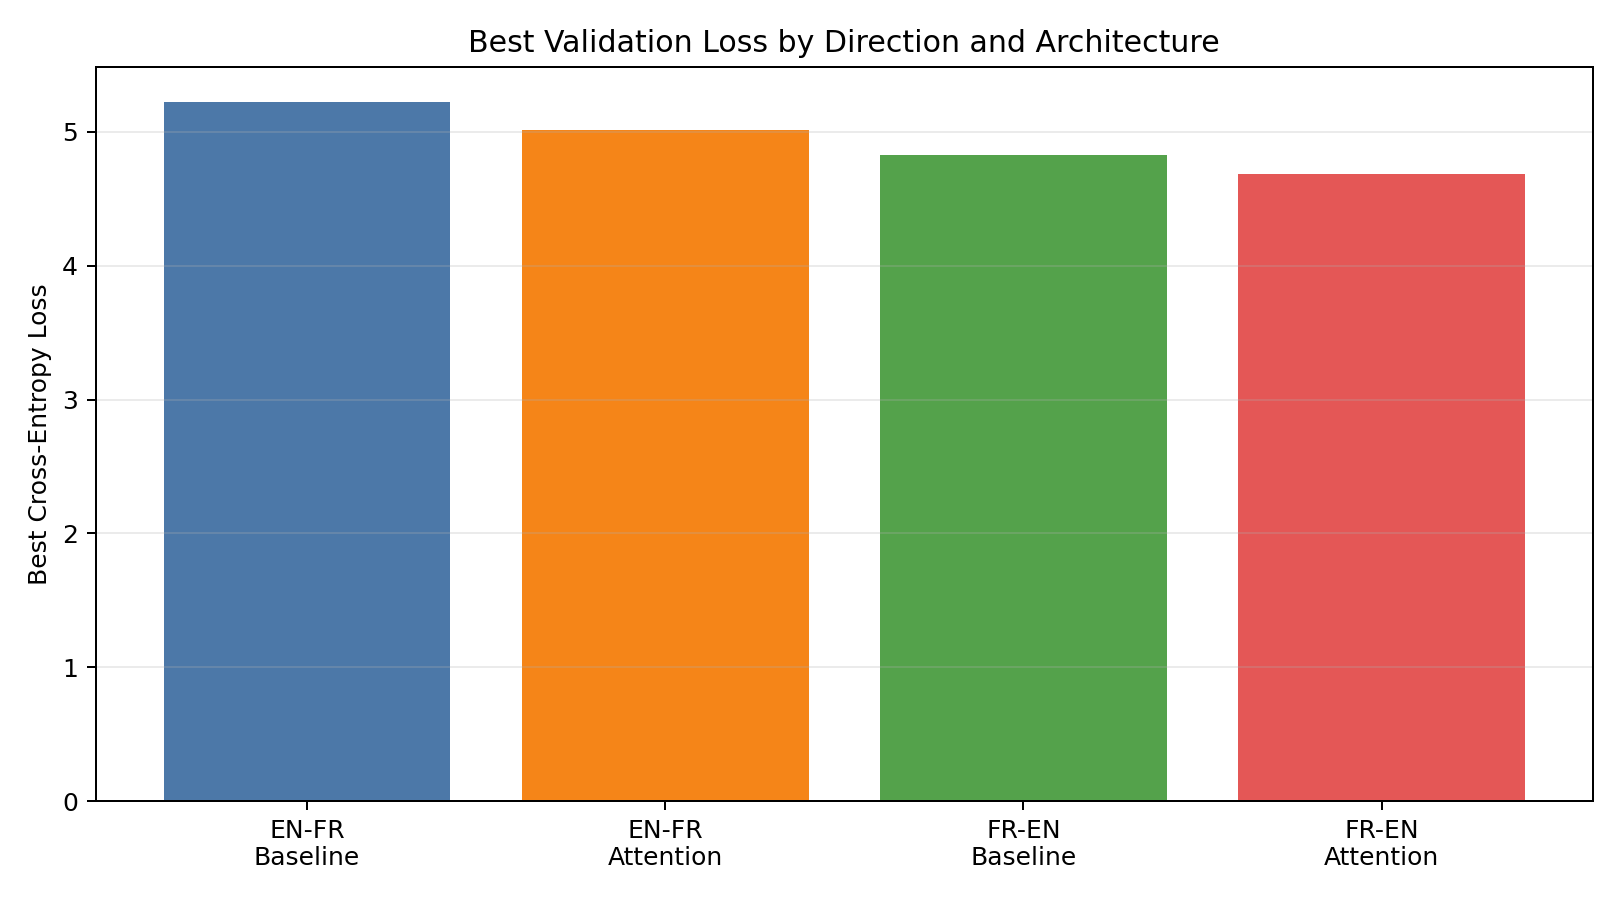

In [5]:
from IPython.display import Image, display
for path in sorted(Path('plots').glob('*.png')):
    print(path)
    display(Image(filename=str(path)))

## Report Transfer Checklist

Use `results/summary.csv`, `results/*_samples.csv`, and the figures in `plots/` to complete `report/homework3_report_template.md`, then export the final report to PDF.